# STEP 1 — Load dataset (FIRST CODE CELL)

In [33]:
import pandas as pd

df = pd.read_csv("../data/raw/complaints.csv")
df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_12124\21003726.py:3: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


# STEP 2 — Understand your data (EDA)

In [38]:
print(df.shape)

(327070, 18)


In [5]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


# STEP 3 — Product distribution

In [35]:
df["Product"].value_counts()

Product
Checking or savings account                                291178
Credit card                                                226686
Money transfer, virtual currency, or money service         145066
Payday loan, title loan, personal loan, or advance loan     16514
Name: count, dtype: int64

# STEP 4 — Missing complaints check

In [41]:
df["Consumer complaint narrative"].isnull().sum()

np.int64(0)

# STEP 5 — Narrative Length Calculation

In [40]:
df["narrative_length"] = (
    df["Consumer complaint narrative"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df["narrative_length"].describe()

count    327070.000000
mean        198.890186
std         226.767384
min           1.000000
25%          81.000000
50%         126.000000
75%         244.000000
max        6469.000000
Name: narrative_length, dtype: float64

In [29]:
df["Product"].value_counts()

Product
Credit card    80667
Name: count, dtype: int64

# STEP 6 — Narrative Length Visualization

Matplotlib is building the font cache; this may take a moment.


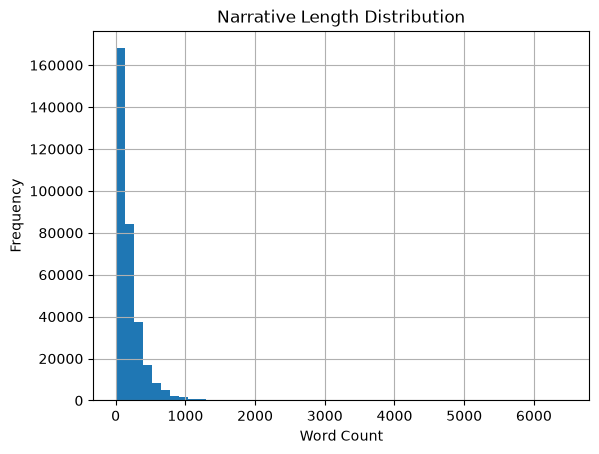

In [42]:
import matplotlib.pyplot as plt

df["narrative_length"].hist(bins=50)

plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

# STEP 7 — Filter required products

In [43]:
products = [
    "Credit card",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service",
    "Payday loan, title loan, personal loan, or advance loan"
]

df = df[df["Product"].isin(products)]

# STEP 8 — Remove empty narratives

In [39]:
df = df.dropna(subset=["Consumer complaint narrative"])

# STEP 9— Clean text

In [23]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Consumer complaint narrative"].apply(clean_text)

# STEP 10 — Save processed file

In [25]:
df.to_csv("../data/filtered_complaints.csv", index=False)
print("File saved successfully")

File saved successfully


# STEP 11 — Markdown Cell

# EDA Summary

The CFPB complaint dataset was analyzed to understand its structure and identify records suitable for a Retrieval-Augmented Generation (RAG) system. Product distribution analysis showed that the largest number of complaints belonged to the Checking or Savings Account category (291,178 complaints), followed by Credit Card complaints (226,686 complaints) and Money Transfer, Virtual Currency, or Money Service complaints (145,066 complaints). Complaints related to Payday Loans, Title Loans, and Personal Loans represented the smallest group, with 16,514 records.

The dataset contained a substantial number of records without consumer complaint narratives. Since narrative text is required for retrieval and question-answering tasks, records with missing narratives were removed during preprocessing. After filtering to the four target product categories and removing empty narratives, the dataset contained 327,070 complaints with usable textual information.

Narrative length analysis revealed significant variation in complaint detail. The average complaint length was approximately 199 words, with a median length of 126 words. While many complaints were relatively short, some exceeded 6,000 words, indicating the presence of highly detailed narratives. To prepare the data for downstream embedding generation and retrieval, the complaint text was normalized by converting text to lowercase, removing special characters, and standardizing whitespace. The resulting dataset is suitable for use in the subsequent stages of the RAG pipeline.
